Ejercicio 1

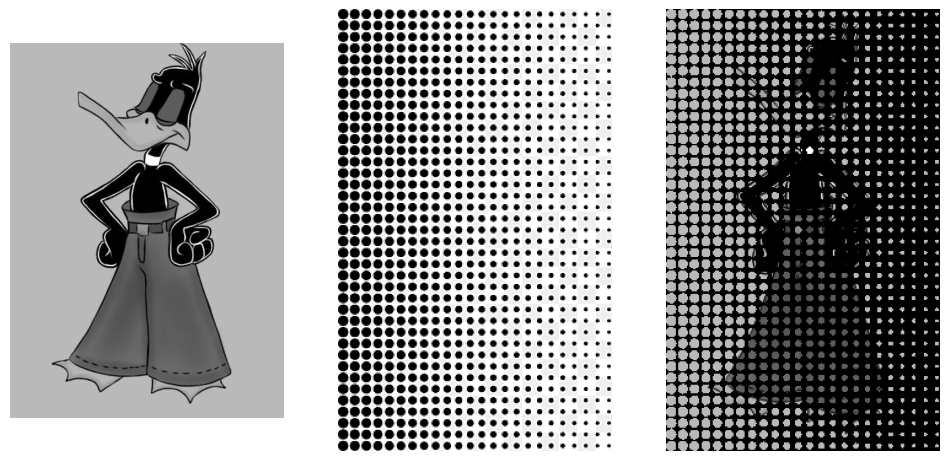

In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

img = cv2.imread('pato.jpg',0)
img2 = cv2.imread('puntos.png',0)

_, mascara = cv2.threshold(img2, 150, 255, cv2.THRESH_BINARY_INV)

if img.shape[:2] != mascara.shape:
    pato = cv2.resize(img, (mascara.shape[1], mascara.shape[0]))

img3 = cv2.bitwise_and(pato, pato, mask=mascara)

plt.figure(figsize=(12,10))
plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img2, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img3, cmap='gray')
plt.axis('off')

plt.show()

Ejercicio 2

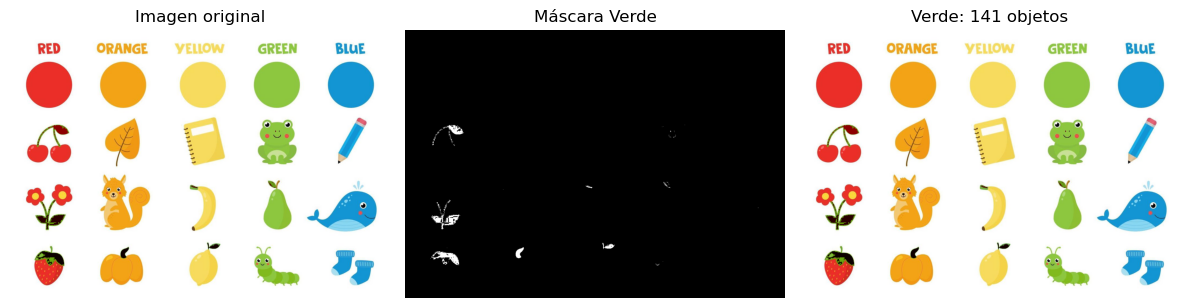

In [54]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def contarColor(img_rgb, rango_bajo, rango_alto):

    mascara = cv2.inRange(img_rgb, rango_bajo, rango_alto)
    contorno,_ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for i,contornos in enumerate(contorno):
        cv2.drawContours(img_rgb,[contornos],-1,(i+1),-1)

    cantidad = len(contorno)
    return cantidad, mascara, img_rgb

img = cv2.imread('colores.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

color = 'Verde'
rango_bajo = np.array([0, 100, 0])
rango_alto = np.array([100, 255, 100])

cantidad, mascara, img_contornos = contarColor(img_rgb, rango_bajo, rango_alto)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Imagen original')

plt.subplot(1, 3, 2)
plt.imshow(mascara, cmap='gray')
plt.axis('off')
plt.title(f'Máscara {color}')

plt.subplot(1, 3, 3)
plt.imshow(img_contornos)
plt.axis('off')
plt.title(f'{color}: {cantidad} objetos')

plt.tight_layout()
plt.show()


Ejercicio 3

Se podria aplicar para la deteccion de rasgos faciales que no son tan visibles a simple vista

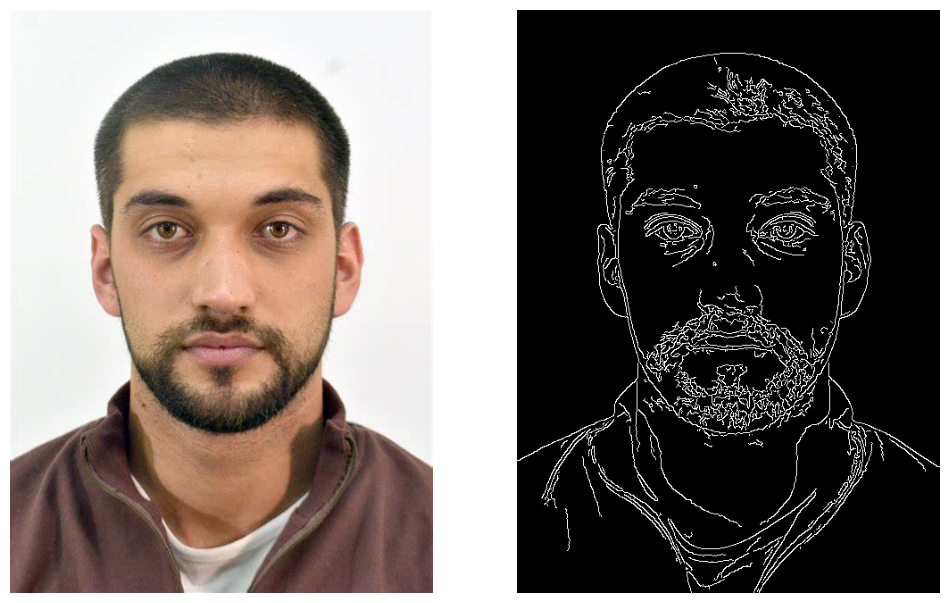

In [70]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

img = cv2.imread('imgRostro1.jpg')
imgGray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

suabizado = cv2.GaussianBlur(imgGray,(3,3),0)
canny = cv2.Canny(suabizado,40,100)

plt.figure(figsize=(12,10))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(canny, cmap='gray')
plt.axis('off')

plt.show()

Contador

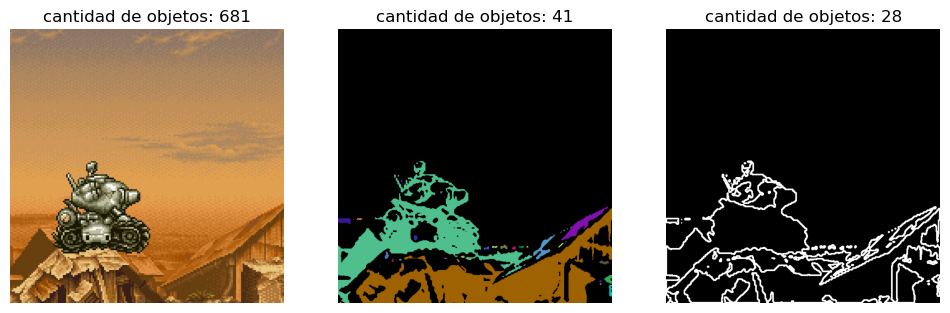

In [65]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar(imagen):
    _,binarizar = cv2.threshold(imagen,127,255,cv2.THRESH_BINARY)
    etiquetar = measure.label(binarizar,connectivity=2)# conectividad con 4 = 2 y conectividad con 8 = 1
    num = np.max(etiquetar)
    return num 



img = cv2.imread('imgGIF3.jpg')
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

imgGray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(imgGray,(7,7),0)
_,binarizada = cv2.threshold(blur,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
#regiones
cant,region = cv2.connectedComponents(binarizada)

colores = np.random.randint(0,255,size=(cant,3),dtype=np.uint8)

colores[0] = [0,0,0]
color_regionb = colores[region]

#fronteras

contorno,_= cv2.findContours(binarizada,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
lineas = cv2.drawContours(np.zeros_like(imgGray),contorno,-1,255,2)

contar1 = contar(imgGray)
contar2 = contar(color_regionb)
contar3 = contar(lineas)

plt.figure(figsize=(12,10))
plt.subplot(1,3,1)
plt.title('img original')
plt.title(f'cantidad de objetos: {contar1}')
plt.imshow(imgRGB)
plt.axis('off')

plt.subplot(1,3,2)
plt.title('region')
plt.imshow(color_regionb)
plt.title(f'cantidad de objetos: {contar2}')
plt.axis('off')

plt.subplot(1,3,3)
plt.title('fronteras')
plt.imshow(lineas, cmap='gray')
plt.title(f'cantidad de objetos: {contar3}')
plt.axis('off')

plt.show()